In [1]:
!pip install seaborn

In [2]:
!pip install matplotlib

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df=pd.read_csv('loan_data.csv')

In [5]:
df.tail()

,Income,Credit_Score,Loan_Approved
35,56000,890.0,1
36,58000,NaN,1
37,60000,930.0,1
38,62000,NaN,1
39,64000,990.0,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Income         40 non-null     int64  
 1   Credit_Score   32 non-null     float64
 2   Loan_Approved  40 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 1.1 KB


In [7]:
df.describe()

,Income,Credit_Score,Loan_Approved
count,40.000000,32.000000,40.00000
mean,44500.000000,801.875000,0.50000
std,11690.451945,105.293369,0.50637
min,25000.000000,600.000000,0.00000
25%,34750.000000,717.500000,0.00000
50%,44500.000000,795.000000,0.50000
75%,54250.000000,882.500000,1.00000
max,64000.000000,990.000000,1.00000


In [8]:
df.isna().sum()

Income           0
Credit_Score     8
Loan_Approved    0
dtype: int64

In [9]:
df['Credit_Score'].dropna()

0     600.0
1     650.0
2     700.0
3     720.0
4     680.0
5     710.0
6     730.0
7     750.0
8     770.0
9     780.0
10    800.0
11    820.0
12    840.0
13    860.0
14    880.0
15    900.0
16    920.0
17    940.0
18    960.0
19    980.0
21    640.0
23    710.0
24    690.0
26    740.0
27    760.0
29    790.0
30    810.0
32    850.0
34    870.0
35    890.0
37    930.0
39    990.0
Name: Credit_Score, dtype: float64

In [10]:
df['Credit_Score']=df['Credit_Score'].fillna(df['Credit_Score'].median(), inplace=True)

C:\Users\Nisha_Classy\AppData\Local\Temp\ipykernel_10088\1962913338.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Credit_Score']=df['Credit_Score'].fillna(df['Credit_Score'].median(), inplace=True)


In [11]:
df['Credit_Score'].isna().sum()

np.int64(0)

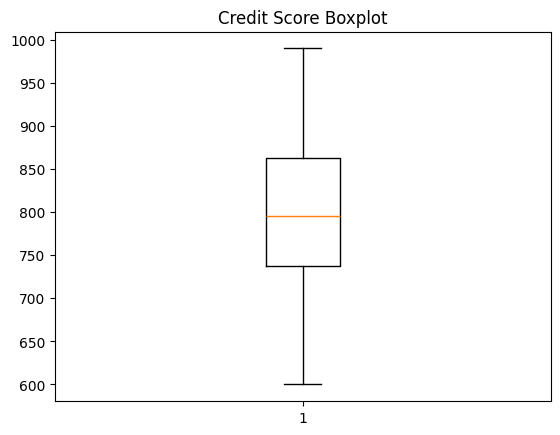

In [12]:


import matplotlib.pyplot as plt
plt.boxplot(df['Credit_Score'])
plt.title("Credit Score Boxplot")
plt.show()

In [13]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

In [14]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

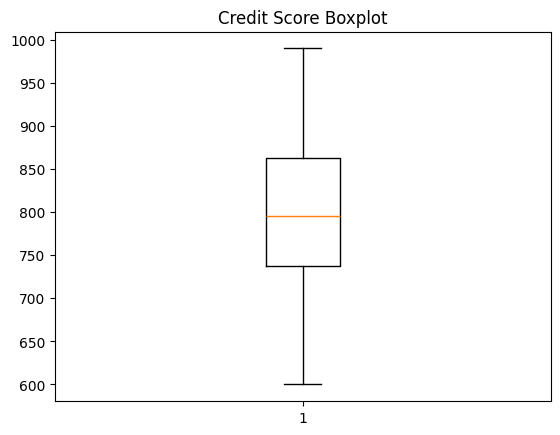

In [15]:
plt.boxplot(df['Credit_Score'])
plt.title("Credit Score Boxplot")
plt.show()

In [ ]:

df.to_csv('loan_data_cleaned.csv', index=False)

#Scaling

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [20]:
X = df.drop('Loan_Approved', axis=1)
y = df['Loan_Approved']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
# Scaling
scaler = StandardScaler()

In [23]:


X_train = scaler.fit_transform(X_train)  # fit ONLY on train
X_test = scaler.transform(X_test)

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
model = LogisticRegression()

In [26]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [27]:
y_pred = model.predict(X_test)

In [34]:
print(y_pred)

[1 1 1 0 0 1 1 0]


In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [37]:

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)


MSE: 0.0


In [30]:
print(confusion_matrix(y_test, y_pred))


[[3 0]
 [0 5]]


In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         5

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



In [32]:
model = LogisticRegression(class_weight='balanced')

In [33]:
print(model)

LogisticRegression(class_weight='balanced')
